# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [36]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
import numpy as np

### Step 1.a Load the data

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

: 

### Step 2.a Assign variables `X` to the features and `y` to the target

In [37]:
X = iris.data
y = iris.target

print(X.head())
print(y.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int32


### Step 2.b print the type of each

In [38]:
print('Type of x:', type(X))
print('Type of y:', type(y))
print('dtype of x :', X.dtypes.values)
print('dtype of y :', y.dtypes)

Type of x: <class 'pandas.core.frame.DataFrame'>
Type of y: <class 'pandas.core.series.Series'>
dtype of x : [dtype('float64') dtype('float64') dtype('float64') dtype('float64')]
dtype of y : int32


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [39]:
print('Unique target values:', y.unique())
print('Target names:', iris.target_names)
print()
print('the target is CATEGORICAL (class labels: 0=setosa, 1=versicolor, 2=virginica)')
print('the task is CLASSIFICATION(multi-class, 3 classes)')

Unique target values: [0 1 2]
Target names: ['setosa' 'versicolor' 'virginica']

the target is CATEGORICAL (class labels: 0=setosa, 1=versicolor, 2=virginica)
the task is CLASSIFICATION(multi-class, 3 classes)


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [40]:
print('X shape (samples, features)' , X.shape)
print('y shape (samples,)' , y.shape)
print(f'\nNumber of samples: {X.shape[0]}')
print(f'Number of features: {X.shape[1]}')
print(f'Feature names  : {list(X.columns)}')

X shape (samples, features) (150, 4)
y shape (samples,) (150,)

Number of samples: 150
Number of features: 4
Feature names  : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [41]:
summary = X.agg(['min', 'max' ,'mean', 'std'])
print(summary)

      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
min            4.300000          2.000000           1.000000          0.100000
max            7.900000          4.400000           6.900000          2.500000
mean           5.843333          3.057333           3.758000          1.199333
std            0.828066          0.435866           1.765298          0.762238


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

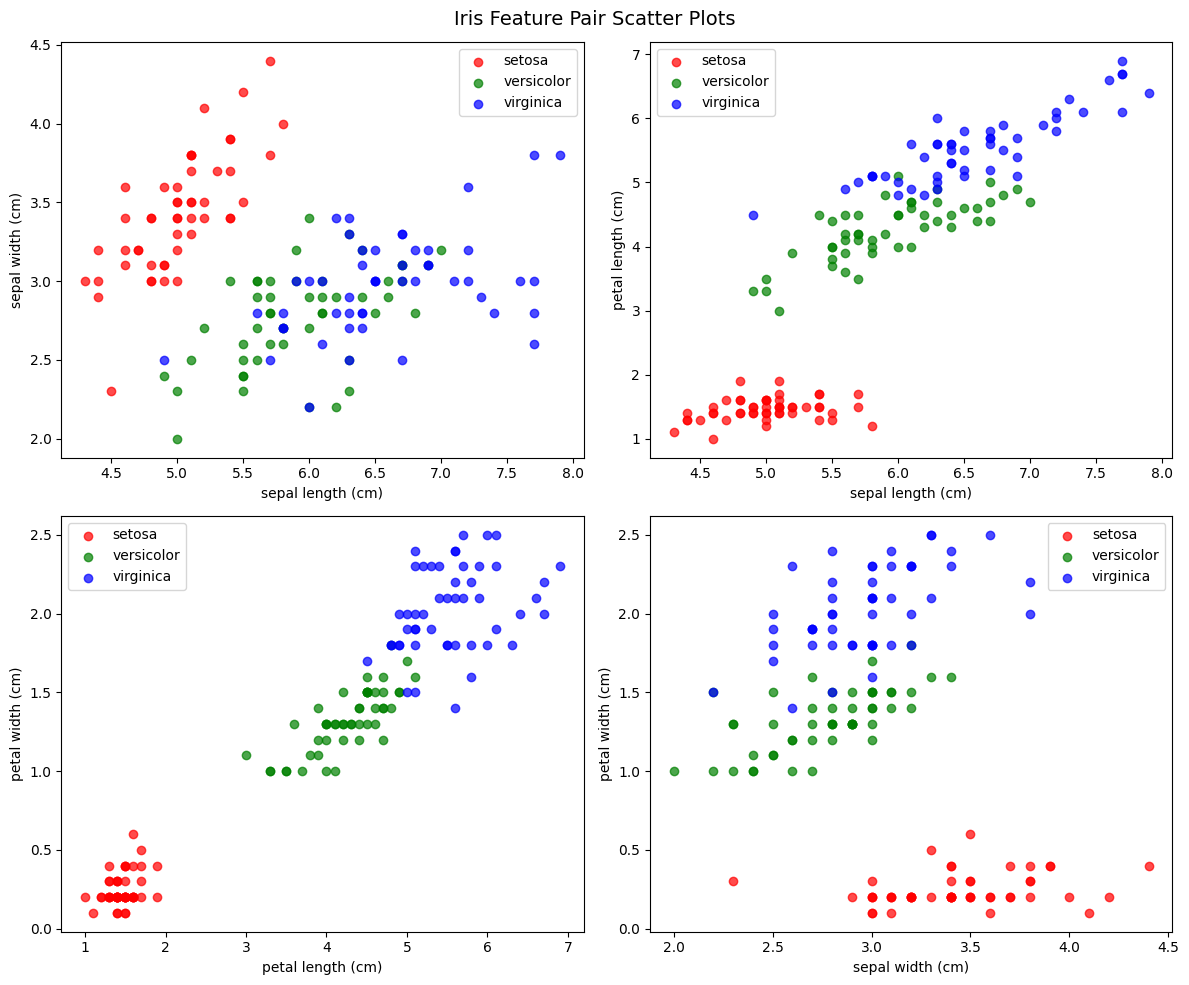

Observation: Petal length vs petal width shows the clearest separation between classes.


In [42]:
colors = ['red', 'green', 'blue']
target_names = iris.target_names

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
feature_pairs = [
    ('sepal length (cm)', 'sepal width (cm)'),
    ('sepal length (cm)', 'petal length (cm)'),
    ('petal length (cm)', 'petal width (cm)'),
    ('sepal width (cm)',  'petal width (cm)'),
]

for ax, (fx, fy) in zip(axes.flatten(), feature_pairs):
    for cls in y.unique():
        mask = y == cls
        ax.scatter(X.loc[mask, fx], X.loc[mask, fy],
                   label=target_names[cls], color=colors[cls], alpha=0.7)
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.legend()

plt.suptitle('Iris Feature Pair Scatter Plots', fontsize=14)
plt.tight_layout()
plt.show()

print('Observation: Petal length vs petal width shows the clearest separation between classes.')

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [43]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]
print(X_petal.head())

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [44]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]
print(X_petal.head())

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


### Step 7. Initialize 2 `LogisticRegression` models

In [45]:
model_sepal = LogisticRegression(max_iter=200, random_state=42)
model_petal = LogisticRegression(max_iter=200, random_state=42)

print('Model 1 (sepal):', model_sepal)
print('Model 2 (petal):', model_petal)

Model 1 (sepal): LogisticRegression(max_iter=200, random_state=42)
Model 2 (petal): LogisticRegression(max_iter=200, random_state=42)


### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [46]:
X_sepal_train, X_sepal_test, y_sepal_train, y_sepal_test = train_test_split(
    X_sepal, y, test_size=0.2, random_state=42, stratify=y
)

X_petal_train, X_petal_test, y_petal_train, y_petal_test = train_test_split(
    X_petal, y, test_size=0.2, random_state=42, stratify=y
)

print('Sepal train/test sizes:', X_sepal_train.shape, X_sepal_test.shape)
print('Petal train/test sizes:', X_petal_train.shape, X_petal_test.shape)
print('Class distribution in y_train:', y_sepal_train.value_counts().to_dict())

Sepal train/test sizes: (120, 2) (30, 2)
Petal train/test sizes: (120, 2) (30, 2)
Class distribution in y_train: {0: 40, 2: 40, 1: 40}


### Step 9.a Train both models

In [47]:
model_sepal.fit(X_sepal_train, y_sepal_train)
model_petal.fit(X_petal_train, y_petal_train)

print('Both models trained successfully.')

Both models trained successfully.


### Step 10. Evaluate and compare both models

In [48]:
from sklearn.metrics import accuracy_score, classification_report

# Sepal model
y_pred_sepal = model_sepal.predict(X_sepal_test)
acc_sepal = accuracy_score(y_sepal_test, y_pred_sepal)

# Petal model
y_pred_petal = model_petal.predict(X_petal_test)
acc_petal = accuracy_score(y_petal_test, y_pred_petal)

print(f'=== Sepal Model Accuracy: {acc_sepal:.4f} ===')
print(classification_report(y_sepal_test, y_pred_sepal, target_names=iris.target_names))

print(f'=== Petal Model Accuracy: {acc_petal:.4f} ===')
print(classification_report(y_petal_test, y_pred_petal, target_names=iris.target_names))

=== Sepal Model Accuracy: 0.7333 ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.62      0.50      0.56        10
   virginica       0.58      0.70      0.64        10

    accuracy                           0.73        30
   macro avg       0.74      0.73      0.73        30
weighted avg       0.74      0.73      0.73        30

=== Petal Model Accuracy: 0.9667 ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

In [49]:
print(f'Sepal features accuracy : {acc_sepal:.4f}')
print(f'Petal features accuracy : {acc_petal:.4f}')
print()
winner = 'Petal' if acc_petal > acc_sepal else 'Sepal'
print(f'>>> {winner} features are better at distinguishing iris flowers.')
print()
print('Yes, it is easy to tell from both the scatter plots (Step 5) and the accuracy scores:')
print('Petal length and width create much cleaner, more separable clusters between the three species.')

Sepal features accuracy : 0.7333
Petal features accuracy : 0.9667

>>> Petal features are better at distinguishing iris flowers.

Yes, it is easy to tell from both the scatter plots (Step 5) and the accuracy scores:
Petal length and width create much cleaner, more separable clusters between the three species.


### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

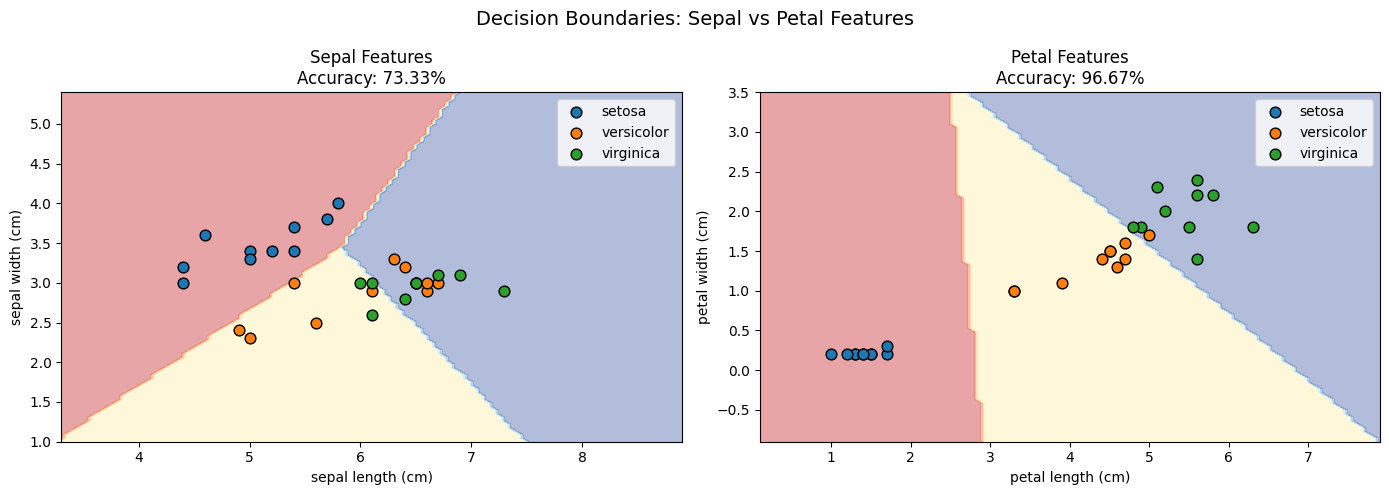

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Model 1: Sepal features ---
disp1 = DecisionBoundaryDisplay.from_estimator(
    model_sepal, X_sepal_train,
    response_method='predict',
    cmap='RdYlBu', alpha=0.4, ax=axes[0]
)
for cls in y.unique():
    mask = y_sepal_test == cls
    axes[0].scatter(
        X_sepal_test.loc[mask, 'sepal length (cm)'],
        X_sepal_test.loc[mask, 'sepal width (cm)'],
        label=iris.target_names[cls], edgecolors='k', s=60
    )
axes[0].set_title(f'Sepal Features\nAccuracy: {acc_sepal:.2%}')
axes[0].set_xlabel('sepal length (cm)')
axes[0].set_ylabel('sepal width (cm)')
axes[0].legend()

# --- Model 2: Petal features ---
disp2 = DecisionBoundaryDisplay.from_estimator(
    model_petal, X_petal_train,
    response_method='predict',
    cmap='RdYlBu', alpha=0.4, ax=axes[1]
)
for cls in y.unique():
    mask = y_petal_test == cls
    axes[1].scatter(
        X_petal_test.loc[mask, 'petal length (cm)'],
        X_petal_test.loc[mask, 'petal width (cm)'],
        label=iris.target_names[cls], edgecolors='k', s=60
    )
axes[1].set_title(f'Petal Features\nAccuracy: {acc_petal:.2%}')
axes[1].set_xlabel('petal length (cm)')
axes[1].set_ylabel('petal width (cm)')
axes[1].legend()

plt.suptitle('Decision Boundaries: Sepal vs Petal Features', fontsize=14)
plt.tight_layout()
plt.show()